<a href="https://colab.research.google.com/github/Anya-ova/pytorch_classifier/blob/raw_neuro_project/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22neuro_project_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.transforms import ToPILImage

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
data_paths = {
      'base': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data',
      'drilling_rig': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/drilling_rig',
      'pumping_unit': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/pumping_unit'
    }

for class_name, path in data_paths.items():
    if class_name != 'base':
        if os.path.exists(path):
            images = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"{class_name}: {len(images)} изображений")
        else:
            print(f"{class_name}: папка не найдена!")

drilling_rig: 25 изображений
pumping_unit: 25 изображений


In [6]:
class SimpleFolderDataset(Dataset):
    """Простой датасет для загрузки изображений из папок"""

    def __init__(self, data_paths, transform=None):
        self.transform = transform
        self.samples = []
        self.classes = ['drilling_rig', 'pumping_unit']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

        # Загружаем изображения из папок
        for class_name in self.classes:
            class_path = data_paths[class_name]
            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))
            else:
                print(f"Папка {class_path} не найдена")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label, img_path  # Возвращаем также путь для отладки
        except Exception as e:
            print(f"Ошибка загрузки {img_path}: {e}")
            # Возвращаем черное изображение в случае ошибки
            dummy_img = Image.new('RGB', (224, 224), color='black')
            if self.transform:
                dummy_img = self.transform(dummy_img)
            return dummy_img, label, img_path

# %%
# Трансформации для изображений
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Создаем датасет
dataset = SimpleFolderDataset(data_paths, transform=transform)
print(f"\nИнформация о датасете:")
print(f"  Всего изображений: {len(dataset)}")
print(f"  Классы: {dataset.classes}")
print(f"  Соотношение классов:")
for class_name in dataset.classes:
    count = sum(1 for _, label, _ in dataset if dataset.idx_to_class[label] == class_name)
    print(f"    {class_name}: {count} изображений ({count/len(dataset)*100:.1f}%)")


Информация о датасете:
  Всего изображений: 50
  Классы: ['drilling_rig', 'pumping_unit']
  Соотношение классов:
    drilling_rig: 25 изображений (50.0%)
    pumping_unit: 25 изображений (50.0%)


In [7]:
models_dict = {
    'AlexNet': {
        'model': models.alexnet(weights=models.AlexNet_Weights.DEFAULT),
        'weights': models.AlexNet_Weights.DEFAULT,
        'preprocess': models.AlexNet_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[1].in_features,
        'feature_layer': 'classifier'
    },
    'DenseNet': {
        'model': models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
        'weights': models.DenseNet121_Weights.DEFAULT,
        'preprocess': models.DenseNet121_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier.in_features,
        'feature_layer': 'features'
    },
    'MobileNet': {
        'model': models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT),
        'weights': models.MobileNet_V3_Small_Weights.DEFAULT,
        'preprocess': models.MobileNet_V3_Small_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[0].in_features,
        'feature_layer': 'features'
    },
    'ResNet50': {
        'model': models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'weights': models.ResNet50_Weights.DEFAULT,
        'preprocess': models.ResNet50_Weights.DEFAULT.transforms(),
        'output_layer': 'fc',
        'in_features': lambda model: model.fc.in_features,
        'feature_layer': 'fc'
    },
    'SwinT': {
        'model': models.swin_t(weights=models.Swin_T_Weights.DEFAULT),
        'weights': models.Swin_T_Weights.DEFAULT,
        'preprocess': models.Swin_T_Weights.DEFAULT.transforms(),
        'output_layer': 'head',
        'in_features': lambda model: model.head.in_features,
        'feature_layer': 'head'
    }
}

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:08<00:00, 27.8MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 72.3MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 52.1MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.0MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:01<00:00, 105MB/s] 


In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nИспользуемое устройство: {device}")

for model_name, model_info in models_dict.items():
    model_info['model'] = model_info['model'].to(device)
    model_info['model'].eval()


Используемое устройство: cpu


In [9]:
def get_device(device_type='auto'):
    """Выбор устройства для вычислений"""
    if device_type == 'auto':
        if torch.cuda.is_available():
            return torch.device('cuda')
        else:
            return torch.device('cpu')
    elif device_type == 'cuda' and torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [10]:
def test_model_on_device(model_info, dataloader, model_name, device_type='cpu',
                         collect_examples=True, max_examples_per_class=2):
    """
    Тестирование модели на конкретном устройстве
    БЕЗ МАППИНГА - просто получаем топ-1 предсказание ImageNet
    """
    device = get_device(device_type)
    model = copy.deepcopy(model_info['model'])
    model = model.to(device)
    model.eval()

    # Словари для сбора примеров
    examples = {
        'success': {0: [], 1: []},  # success[class_idx] = список примеров
        'failure': {0: [], 1: []}   # failure[class_idx] = список примеров
    }

    # Статистика
    total = 0
    inference_times = []
    all_predictions = []
    all_confidences = []
    all_actual = []

    # Классы ImageNet (1000 классов)
    imagenet_classes = model_info['weights'].meta["categories"]

    with torch.no_grad():
        for batch_idx, (images, labels, img_paths) in enumerate(tqdm(dataloader,
                                                                     desc=f"{model_name} ({device_type})",
                                                                     leave=False)):
            images = images.to(device)
            labels = labels.to(device)

            # Измерение времени
            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append((end_time - start_time) * 1000)  # мс

            # Получаем предсказания
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

            # Получаем топ-5 предсказаний для анализа
            top5_probs, top5_indices = torch.topk(probabilities, 5, dim=1)

            total += labels.size(0)

            for i in range(len(labels)):
                actual_label = labels[i].item()
                predicted_label = predicted_idx[i].item()
                pred_confidence = confidence[i].item()

                # Получаем имена классов
                actual_class_name = dataset.idx_to_class[actual_label]
                predicted_imagenet_class = imagenet_classes[predicted_label]

                # БЕЗ МАППИНГА: просто сохраняем предсказание ImageNet
                # В режиме предобученной модели мы не оцениваем "правильность"
                # правильность оценивается только после донастройки
                is_correct = False  # По умолчанию False для предобученных моделей

                # Сохраняем результаты
                all_predictions.append(predicted_label)
                all_confidences.append(pred_confidence)
                all_actual.append(actual_label)

                # Собираем примеры если нужно
                if collect_examples:
                    example_data = {
                        'image': images[i].cpu(),
                        'actual_label': actual_label,
                        'actual_class': actual_class_name,
                        'predicted_imagenet': predicted_imagenet_class,
                        'predicted_idx': predicted_label,
                        'confidence': pred_confidence,
                        'is_correct': is_correct,
                        'img_path': img_paths[i],
                        'top5_classes': [imagenet_classes[idx.item()] for idx in top5_indices[i]],
                        'top5_probs': top5_probs[i].cpu().numpy()
                    }

                    # Для предобученных моделей все примеры считаем "информативными"
                    # без разделения на успешные/неуспешные
                    if len(examples['success'][actual_label]) < max_examples_per_class:
                        examples['success'][actual_label].append(example_data)
                    elif len(examples['failure'][actual_label]) < max_examples_per_class:
                        examples['failure'][actual_label].append(example_data)

    # Вычисляем метрики
    # ДЛЯ ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ НЕ ВЫЧИСЛЯЕМ ТОЧНОСТЬ (нет маппинга)
    avg_inference_time = np.mean(inference_times) if inference_times else 0

    return {
        'avg_inference_time': avg_inference_time,
        'total_images': total,
        'device': device_type,
        'model_name': model_name,
        'examples': examples,
        'all_predictions': all_predictions,
        'all_confidences': all_confidences,
        'all_actual': all_actual,
        'imagenet_classes': imagenet_classes
    }

In [11]:
def adapt_model_for_our_classes(model_name, model_info, num_classes=2):
    """Адаптация модели под наши 2 класса (как в шаблоне)"""

    if model_name == 'AlexNet':
        model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == 'DenseNet':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(1024, num_classes)

    elif model_name == 'MobileNet':
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(1024, num_classes)

    elif model_name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(2048, num_classes)

    elif model_name == 'SwinT':
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        model.head = nn.Linear(768, num_classes)

    return model

In [12]:
adapted_models = {}
for model_name, model_info in models_dict.items():
    adapted_models[model_name] = adapt_model_for_our_classes(model_name, model_info, num_classes=2)
    print(f"Адаптирована модель: {model_name}")

Адаптирована модель: AlexNet
Адаптирована модель: DenseNet
Адаптирована модель: MobileNet
Адаптирована модель: ResNet50
Адаптирована модель: SwinT


In [13]:
def train_adapted_model(model, train_loader, val_loader, model_name="", epochs=15, device=None):
    """Обучение адаптированной модели"""
    if device is None:
        device = get_device()

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_accuracies = []

    print(f"\nОбучение {model_name}...")

    for epoch in range(epochs):
        # Обучение
        model.train()
        total_loss = 0
        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        train_losses.append(total_loss / len(train_loader))
        val_accuracies.append(accuracy)

        if (epoch + 1) % 5 == 0:
            print(f'  Эпоха {epoch+1}/{epochs}, Потери: {total_loss/len(train_loader):.4f}, '
                  f'Точность: {accuracy:.2f}%')

    final_accuracy = val_accuracies[-1] if val_accuracies else 0
    print(f"Финальная точность {model_name}: {final_accuracy:.2f}%")

    return model, train_losses, val_accuracies, final_accuracy

In [14]:
def test_adapted_model(model, dataloader, model_name="", device=None, collect_examples=True):
    """Тестирование адаптированной модели"""
    if device is None:
        device = get_device()

    model = model.to(device)
    model.eval()

    correct = 0
    total = 0
    inference_times = []
    all_predictions = []
    all_confidences = []
    all_actual = []

    # Для сбора примеров
    examples = {
        'success': {0: [], 1: []},
        'failure': {0: [], 1: []}
    }

    with torch.no_grad():
        for batch_idx, (images, labels, img_paths) in enumerate(tqdm(dataloader,
                                                                     desc=f"Тестирование {model_name}")):
            images = images.to(device)
            labels = labels.to(device)

            # Измерение времени
            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append((end_time - start_time) * 1000)

            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Сохраняем результаты
            for i in range(len(labels)):
                all_predictions.append(predicted[i].item())
                all_confidences.append(confidence[i].item())
                all_actual.append(labels[i].item())

                # Собираем примеры
                if collect_examples:
                    actual_label = labels[i].item()
                    actual_class = dataset.idx_to_class[actual_label]
                    predicted_label = predicted[i].item()
                    predicted_class = dataset.idx_to_class[predicted_label]

                    example_data = {
                        'image': images[i].cpu(),
                        'actual_label': actual_label,
                        'actual_class': actual_class,
                        'predicted_label': predicted_label,
                        'predicted_class': predicted_class,
                        'confidence': confidence[i].item(),
                        'is_correct': predicted[i].item() == labels[i].item(),
                        'img_path': img_paths[i]
                    }

                    if predicted[i].item() == labels[i].item():
                        if len(examples['success'][actual_label]) < 2:
                            examples['success'][actual_label].append(example_data)
                    else:
                        if len(examples['failure'][actual_label]) < 2:
                            examples['failure'][actual_label].append(example_data)

    accuracy = 100 * correct / total if total > 0 else 0
    avg_inference_time = np.mean(inference_times) if inference_times else 0

    return {
        'accuracy': accuracy,
        'avg_inference_time': avg_inference_time,
        'total_images': total,
        'correct_predictions': correct,
        'model_name': model_name,
        'examples': examples,
        'all_predictions': all_predictions,
        'all_confidences': all_confidences,
        'all_actual': all_actual
    }

In [15]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

print(f"\nРазбиение датасета:")
print(f"  Обучающая выборка: {len(train_dataset)} изображений")
print(f"  Валидационная выборка: {len(val_dataset)} изображений")


Разбиение датасета:
  Обучающая выборка: 40 изображений
  Валидационная выборка: 10 изображений


In [16]:
adapted_results = {}
trained_models = {}
adapted_examples = {}

print("\n" + "="*60)
print("ОБУЧЕНИЕ АДАПТИРОВАННЫХ МОДЕЛЕЙ")
print("="*60)

for model_name in models_dict.keys():
    print(f"\n--- {model_name} ---")

    # Обучаем модель
    trained_model, train_losses, val_accuracies, final_accuracy = train_adapted_model(
        adapted_models[model_name], train_loader, val_loader,
        model_name=model_name, epochs=15, device=device
    )

    trained_models[model_name] = trained_model

    # Тестируем на всем датасете
    result = test_adapted_model(
        trained_model, test_loader, model_name=model_name,
        device=device, collect_examples=True
    )

    adapted_results[model_name] = result
    adapted_examples[model_name] = result['examples']

    print(f"  Итоговая точность: {result['accuracy']:.2f}%")
    print(f"  Среднее время инференса: {result['avg_inference_time']:.2f} мс")
    print(f"  Правильно: {result['correct_predictions']}/{result['total_images']}")


ОБУЧЕНИЕ АДАПТИРОВАННЫХ МОДЕЛЕЙ

--- AlexNet ---

Обучение AlexNet...
  Эпоха 5/15, Потери: 0.4043, Точность: 50.00%
  Эпоха 10/15, Потери: 0.1924, Точность: 80.00%
  Эпоха 15/15, Потери: 4.7672, Точность: 100.00%
Финальная точность AlexNet: 100.00%


Тестирование AlexNet: 100%|██████████| 50/50 [00:04<00:00, 10.62it/s]


  Итоговая точность: 94.00%
  Среднее время инференса: 51.44 мс
  Правильно: 47/50

--- DenseNet ---

Обучение DenseNet...
  Эпоха 5/15, Потери: 0.1133, Точность: 100.00%
  Эпоха 10/15, Потери: 0.2007, Точность: 100.00%
  Эпоха 15/15, Потери: 0.0402, Точность: 100.00%
Финальная точность DenseNet: 100.00%


Тестирование DenseNet: 100%|██████████| 50/50 [00:12<00:00,  4.10it/s]


  Итоговая точность: 96.00%
  Среднее время инференса: 197.65 мс
  Правильно: 48/50

--- MobileNet ---

Обучение MobileNet...
  Эпоха 5/15, Потери: 0.2301, Точность: 90.00%
  Эпоха 10/15, Потери: 0.0008, Точность: 60.00%
  Эпоха 15/15, Потери: 0.0007, Точность: 90.00%
Финальная точность MobileNet: 90.00%


Тестирование MobileNet: 100%|██████████| 50/50 [00:02<00:00, 18.09it/s]


  Итоговая точность: 98.00%
  Среднее время инференса: 14.72 мс
  Правильно: 49/50

--- ResNet50 ---

Обучение ResNet50...
  Эпоха 5/15, Потери: 0.0055, Точность: 100.00%
  Эпоха 10/15, Потери: 0.0910, Точность: 90.00%
  Эпоха 15/15, Потери: 0.2991, Точность: 80.00%
Финальная точность ResNet50: 80.00%


Тестирование ResNet50: 100%|██████████| 50/50 [00:13<00:00,  3.63it/s]


  Итоговая точность: 74.00%
  Среднее время инференса: 231.64 мс
  Правильно: 37/50

--- SwinT ---

Обучение SwinT...
  Эпоха 5/15, Потери: 0.6642, Точность: 80.00%
  Эпоха 10/15, Потери: 0.6760, Точность: 60.00%
  Эпоха 15/15, Потери: 0.7183, Точность: 50.00%
Финальная точность SwinT: 50.00%


Тестирование SwinT: 100%|██████████| 50/50 [00:17<00:00,  2.92it/s]

  Итоговая точность: 68.00%
  Среднее время инференса: 297.67 мс
  Правильно: 34/50


/tmp/ipython-input-263748650.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(model_names, rotation=45, ha='right')
/tmp/ipython-input-263748650.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(model_names, rotation=45, ha='right')


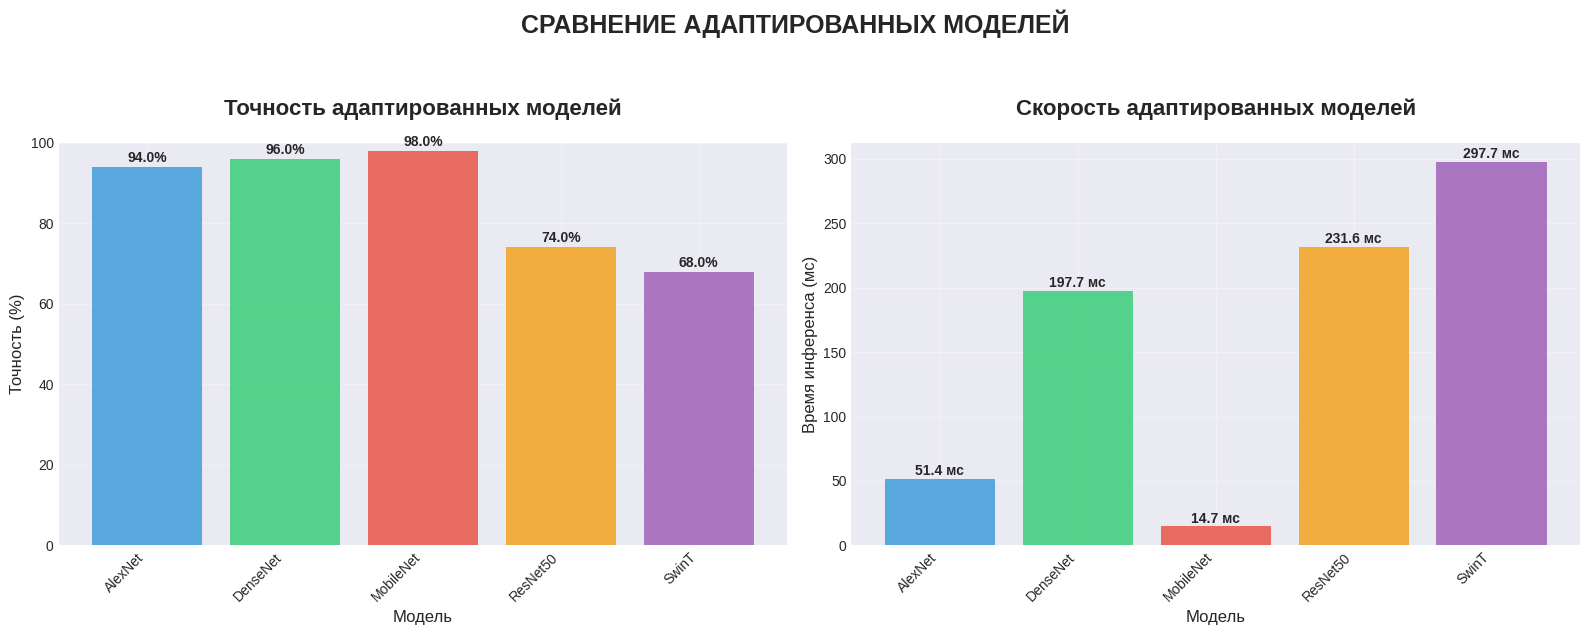

In [17]:
def plot_adapted_models_comparison(adapted_results):
    """График сравнения адаптированных моделей"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    model_names = list(models_dict.keys())

    # График точности
    ax1.set_title('Точность адаптированных моделей', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Модель', fontsize=12)
    ax1.set_ylabel('Точность (%)', fontsize=12)

    accuracies = [adapted_results[model]['accuracy'] for model in model_names]

    bars = ax1.bar(model_names, accuracies, alpha=0.8,
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])

    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 100])

    # Добавляем значения на столбцы
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # График скорости
    ax2.set_title('Скорость адаптированных моделей', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Модель', fontsize=12)
    ax2.set_ylabel('Время инференса (мс)', fontsize=12)

    inference_times = [adapted_results[model]['avg_inference_time'] for model in model_names]

    bars = ax2.bar(model_names, inference_times, alpha=0.8,
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])

    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar, time_val in zip(bars, inference_times):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{time_val:.1f} мс', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle('СРАВНЕНИЕ АДАПТИРОВАННЫХ МОДЕЛЕЙ', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Рисуем график
plot_adapted_models_comparison(adapted_results)

In [18]:
def test_speed_on_devices():
    """Тестирование скорости на CPU и GPU (без обучения)"""

    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ СКОРОСТИ НА CPU И GPU")
    print("="*60)

    devices_to_test = ['cpu']
    if torch.cuda.is_available():
        devices_to_test.append('cuda')

    speed_results = {}

    for device_type in devices_to_test:
        print(f"\nУстройство: {device_type.upper()}")
        device_speeds = {}

        for model_name, model_info in models_dict.items():
            print(f"  Тестируем {model_name}...", end=' ')

            device = get_device(device_type)
            model = copy.deepcopy(model_info['model'])
            model = model.to(device)
            model.eval()

            # Тестируем скорость
            inference_times = []

            with torch.no_grad():
                for images, _, _ in test_loader:
                    images = images.to(device)

                    start_time = time.time()
                    _ = model(images)
                    end_time = time.time()

                    inference_times.append((end_time - start_time) * 1000)

            avg_time = np.mean(inference_times) if inference_times else 0
            device_speeds[model_name] = avg_time

            print(f"{avg_time:.1f} мс")

        speed_results[device_type] = device_speeds

    return speed_results

# %%
# Тестируем скорость
speed_results = test_speed_on_devices()


ТЕСТИРОВАНИЕ СКОРОСТИ НА CPU И GPU

Устройство: CPU
  Тестируем AlexNet... 68.6 мс
  Тестируем DenseNet... 185.0 мс
  Тестируем MobileNet... 18.4 мс
  Тестируем ResNet50... 234.5 мс
  Тестируем SwinT... 298.0 мс


In [19]:
def plot_speed_comparison_devices(speed_results):
    """График сравнения скорости на CPU и GPU"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    model_names = list(models_dict.keys())

    # График скорости
    ax1.set_title('Скорость инференса на разных устройствах', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Модель', fontsize=12)
    ax1.set_ylabel('Время (мс)', fontsize=12)
    ax1.set_yscale('log')  # Логарифмическая шкала

    x = np.arange(len(model_names))
    width = 0.35

    # Время на CPU
    cpu_times = []
    for model_name in model_names:
        if 'cpu' in speed_results and model_name in speed_results['cpu']:
            cpu_times.append(speed_results['cpu'][model_name])
        else:
            cpu_times.append(0)

    # Время на GPU
    gpu_times = []
    for model_name in model_names:
        if 'cuda' in speed_results and model_name in speed_results['cuda']:
            gpu_times.append(speed_results['cuda'][model_name])
        else:
            gpu_times.append(0)

    bars1 = ax1.bar(x - width/2, cpu_times, width, label='CPU', alpha=0.8, color='#3498db')
    bars2 = ax1.bar(x + width/2, gpu_times, width, label='GPU', alpha=0.8, color='#e74c3c')

    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, which='both')

    # Добавляем значения
    for bar, t in zip(bars1, cpu_times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{t:.1f} мс', ha='center', va='bottom', fontsize=9, fontweight='bold')

    for bar, t in zip(bars2, gpu_times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{t:.1f} мс', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # График ускорения
    ax2.set_title('Ускорение на GPU относительно CPU', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Модель', fontsize=12)
    ax2.set_ylabel('Коэффициент ускорения', fontsize=12)

    speedup_factors = []
    for i, model_name in enumerate(model_names):
        if cpu_times[i] > 0 and gpu_times[i] > 0:
            speedup = cpu_times[i] / gpu_times[i]
            speedup_factors.append(speedup)
        else:
            speedup_factors.append(0)

    colors = ['#2ecc71' if s > 1 else '#e74c3c' for s in speedup_factors]
    bars3 = ax2.bar(x, speedup_factors, width, color=colors, alpha=0.8)

    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    # Добавляем значения
    for i, speedup in enumerate(speedup_factors):
        ax2.text(i, speedup + 0.1, f'{speedup:.1f}x', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    plt.suptitle('СРАВНЕНИЕ СКОРОСТИ НА CPU И GPU', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Рисуем график скорости
plot_speed_comparison_devices(speed_results)

/tmp/ipython-input-1427911817.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [20]:
def denormalize(tensor):
    """Денормализация тензора для отображения"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)


20 ПРИМЕРОВ КЛАССИФИКАЦИИ АДАПТИРОВАННЫХ МОДЕЛЕЙ


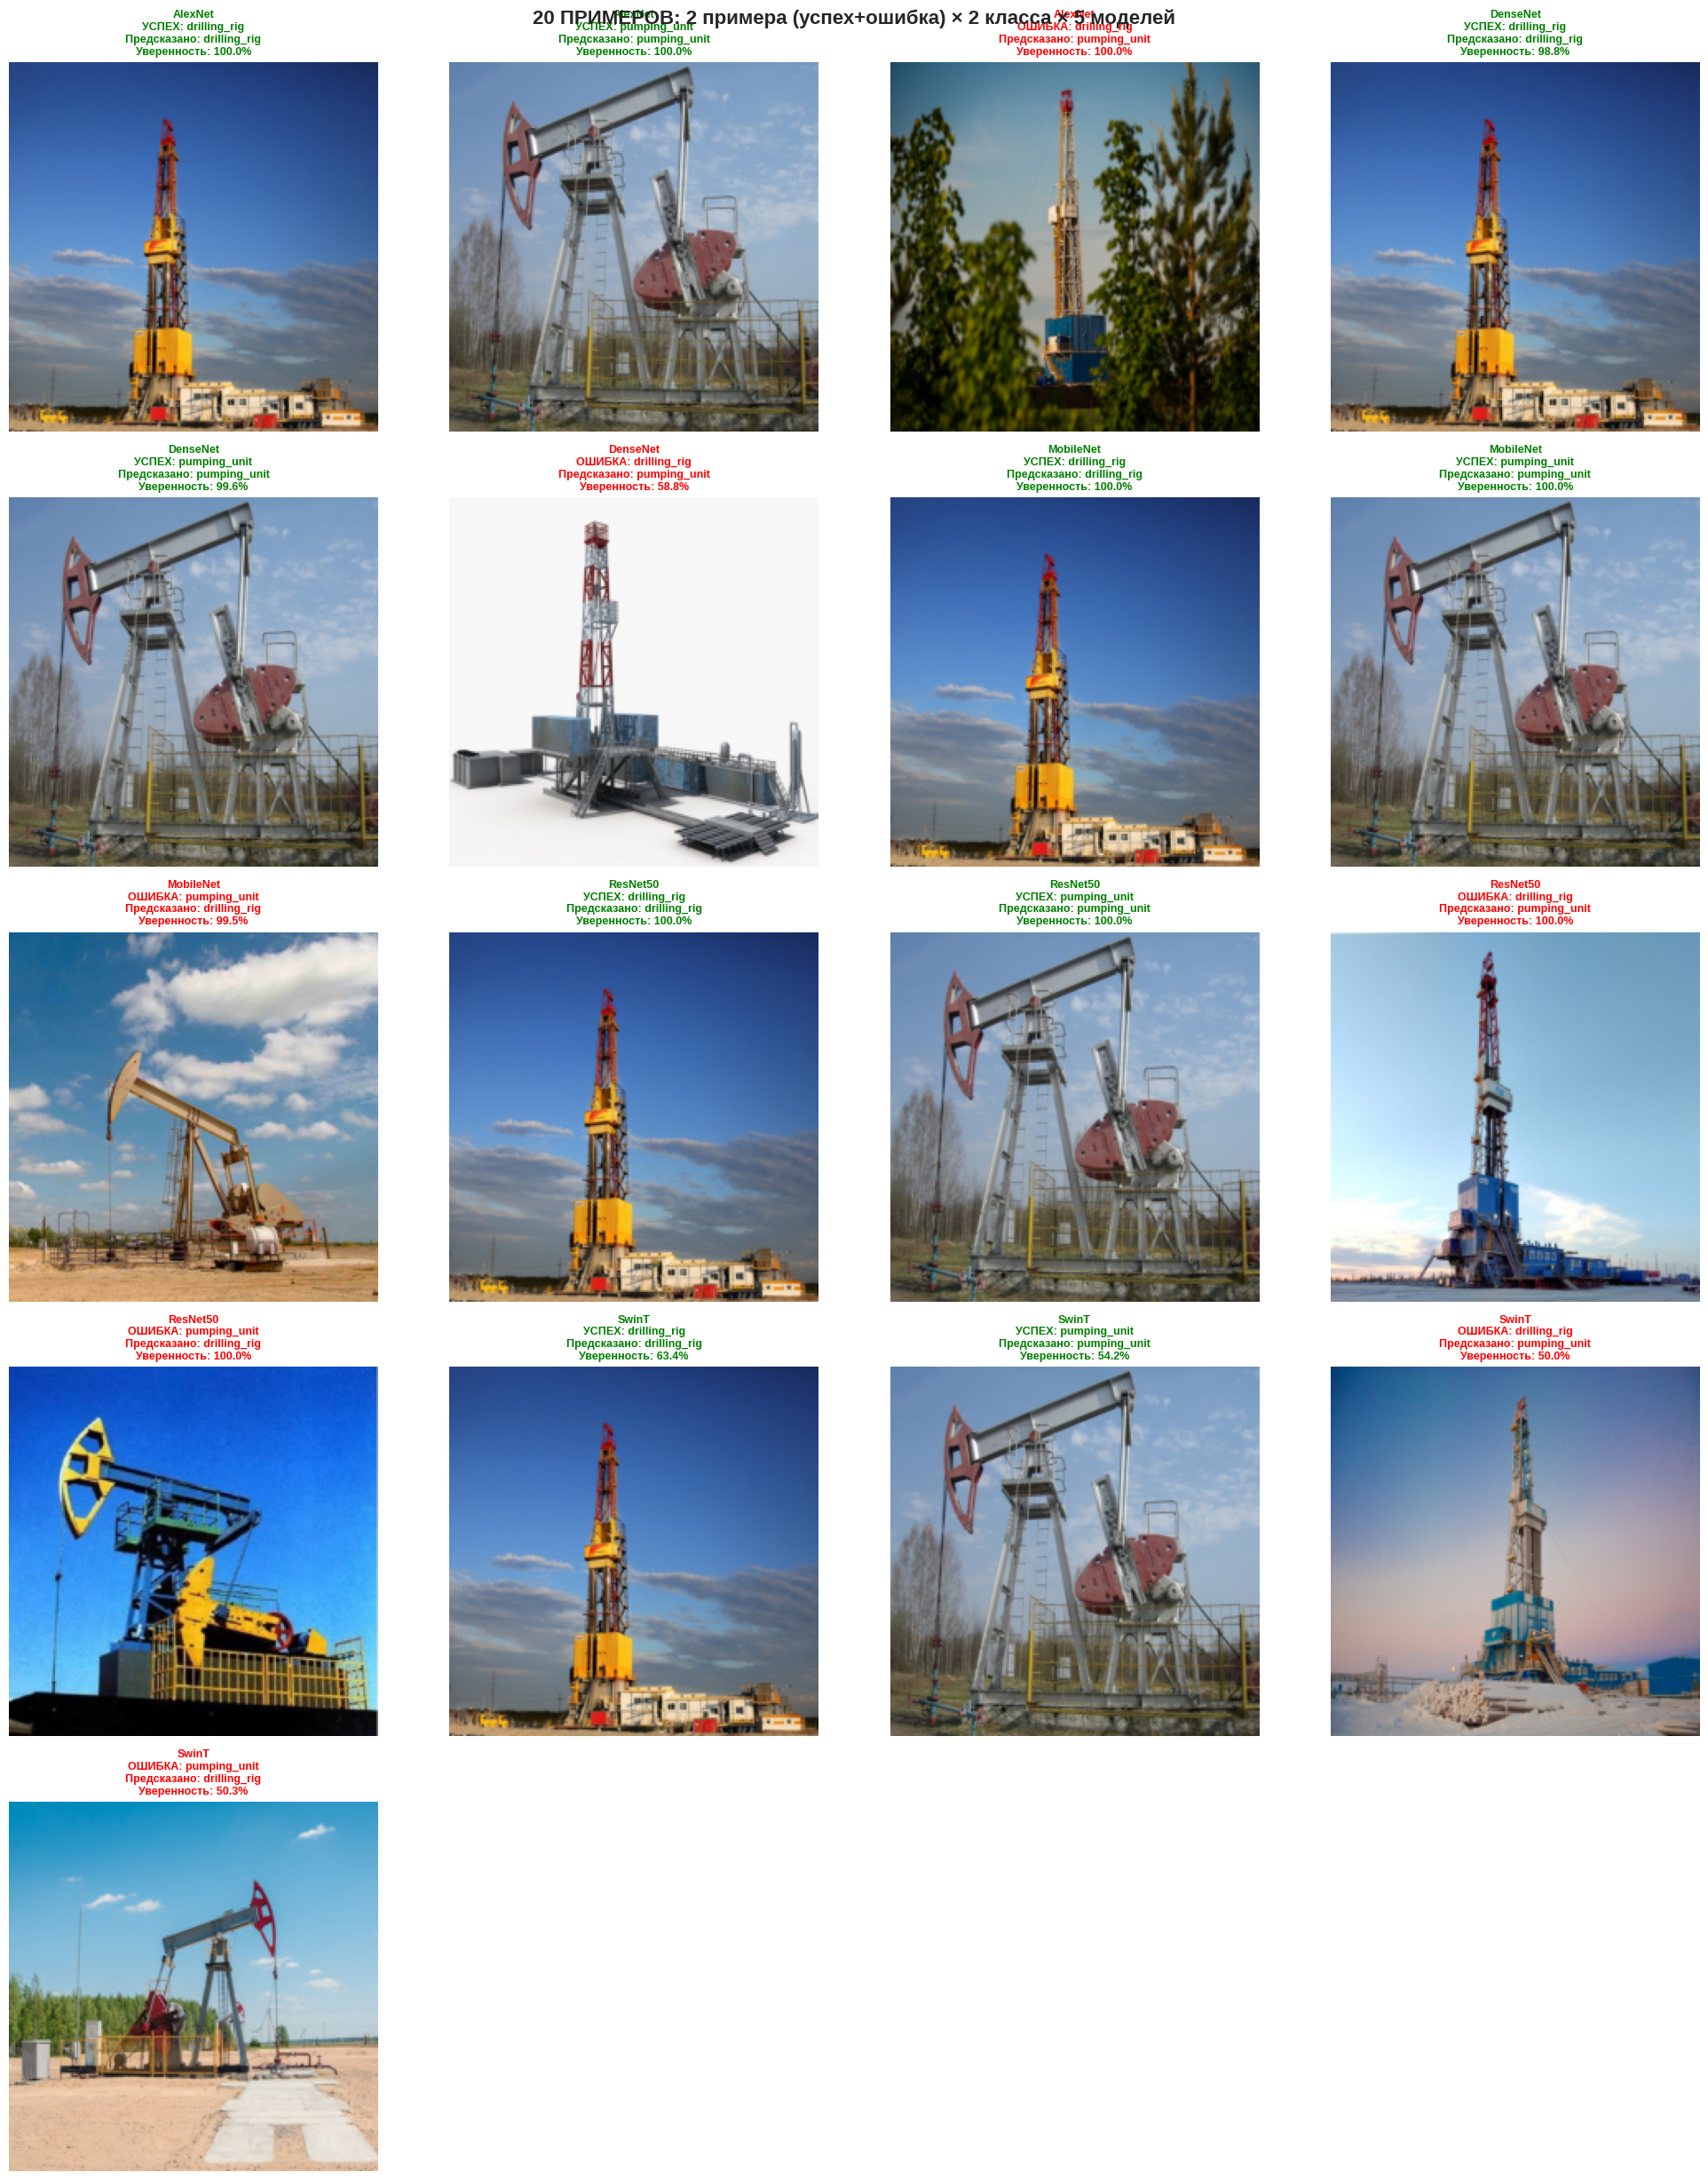

In [21]:
def display_adapted_examples(adapted_examples):
    """Отображение 20 примеров классификации адаптированных моделей"""

    print(f"\n{'='*80}")
    print(f"20 ПРИМЕРОВ КЛАССИФИКАЦИИ АДАПТИРОВАННЫХ МОДЕЛЕЙ")
    print('='*80)

    to_pil = ToPILImage()
    model_names = list(models_dict.keys())

    # Создаем большую фигуру
    fig = plt.figure(figsize=(20, 25))

    # Счетчик для subplot'ов
    plot_idx = 1

    for model_idx, model_name in enumerate(model_names):
        if model_name not in adapted_examples:
            continue

        examples = adapted_examples[model_name]

        # Успешные примеры (по 1 для каждого класса)
        for class_idx in [0, 1]:
            class_name = dataset.idx_to_class[class_idx]
            success_examples = examples['success'][class_idx]

            for example_idx, example in enumerate(success_examples[:1]):  # Берем 1 пример
                img = denormalize(example['image'])

                ax = plt.subplot(5, 4, plot_idx)
                ax.imshow(to_pil(img))

                title = f"{model_name}\nУСПЕХ: {example['actual_class']}"
                title += f"\nПредсказано: {example['predicted_class']}"
                title += f"\nУверенность: {example['confidence']:.1%}"

                ax.set_title(title, fontsize=9, fontweight='bold', color='green')
                ax.axis('off')

                plot_idx += 1

        # Неуспешные примеры (по 1 для каждого класса)
        for class_idx in [0, 1]:
            class_name = dataset.idx_to_class[class_idx]
            failure_examples = examples['failure'][class_idx]

            for example_idx, example in enumerate(failure_examples[:1]):  # Берем 1 пример
                img = denormalize(example['image'])

                ax = plt.subplot(5, 4, plot_idx)
                ax.imshow(to_pil(img))

                title = f"{model_name}\nОШИБКА: {example['actual_class']}"
                title += f"\nПредсказано: {example['predicted_class']}"
                title += f"\nУверенность: {example['confidence']:.1%}"

                ax.set_title(title, fontsize=9, fontweight='bold', color='red')
                ax.axis('off')

                plot_idx += 1

    plt.suptitle('20 ПРИМЕРОВ: 2 примера (успех+ошибка) × 2 класса × 5 моделей',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Отображаем примеры
display_adapted_examples(adapted_examples)

In [ ]:
def finetune_swint_with_feature_extraction(dataset, train_ratio=0.8, epochs=15):
    """Донастройка SwinT с извлечением признаков и PCA"""

    print("\n" + "="*60)
    print("ДОНАСТРОЙКА SWIN-T С ИЗВЛЕЧЕНИЕМ ПРИЗНАКОВ")
    print("="*60)

    device = get_device()

    # 1. Разбиваем датасет
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print(f"Обучающая выборка: {len(train_dataset)} изображений")
    print(f"Валидационная выборка: {len(val_dataset)} изображений")

    # 2. Создаем оригинальную модель для извлечения признаков (до донастройки)
    original_swint = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
    original_swint.eval()
    original_swint = original_swint.to(device)

    # Извлекаем признаки из оригинальной модели (до полносвязного слоя)
    print("\nИзвлечение признаков из оригинальной модели...")

    # Создаем feature extractor
    feature_extractor = copy.deepcopy(original_swint)
    # Заменяем head на Identity для извлечения признаков перед классификатором
    feature_extractor.head = nn.Identity()
    feature_extractor.eval()
    feature_extractor = feature_extractor.to(device)

    original_features = []
    original_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            features = feature_extractor(images)
            original_features.append(features.cpu().numpy())
            original_labels.append(labels.numpy())

    original_features = np.vstack(original_features)
    original_labels = np.concatenate(original_labels)

    # 3. Создаем и обучаем донастроенную модель
    swint_finetuned = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)

    # Заменяем последний слой
    num_features = swint_finetuned.head.in_features
    swint_finetuned.head = nn.Linear(num_features, 2)

    swint_finetuned = swint_finetuned.to(device)

    # Обучение
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(swint_finetuned.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    print("\nОбучение донастроенной модели...")
    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Обучение
        swint_finetuned.train()
        train_loss = 0
        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = swint_finetuned(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        swint_finetuned.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = swint_finetuned(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Эпоха {epoch+1}/{epochs}: Потери={avg_train_loss:.4f}, "
                  f"Точность={val_accuracy:.2f}%")

        scheduler.step()

    # 4. Извлекаем признаки из донастроенной модели
    print("\nИзвлечение признаков из донастроенной модели...")

    finetuned_features = []
    finetuned_labels = []
    finetuned_correct = 0
    finetuned_total = 0

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = swint_finetuned(images)
            _, predicted = torch.max(outputs, 1)

            finetuned_total += labels.size(0)
            finetuned_correct += (predicted == labels).sum().item()

            finetuned_features.append(outputs.cpu().numpy())
            finetuned_labels.append(labels.cpu().numpy())

    finetuned_accuracy = 100 * finetuned_correct / finetuned_total
    finetuned_features = np.vstack(finetuned_features)
    finetuned_labels = np.concatenate(finetuned_labels)

    print(f"Точность донастроенной SwinT: {finetuned_accuracy:.2f}%")

    # 5. Сравниваем с адаптированной версией
    original_adapted_accuracy = adapted_results['SwinT']['accuracy'] if 'SwinT' in adapted_results else 0

    print(f"\nСравнение:")
    print(f"  Адаптированная SwinT (обученная): {original_adapted_accuracy:.2f}%")
    print(f"  SwinT с донастройкой: {finetuned_accuracy:.2f}%")
    print(f"  Разница: {finetuned_accuracy - original_adapted_accuracy:.2f}%")

    return {
        'model': swint_finetuned,
        'finetuned_accuracy': finetuned_accuracy,
        'original_adapted_accuracy': original_adapted_accuracy,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'original_features': original_features,
        'original_labels': original_labels,
        'finetuned_features': finetuned_features,
        'finetuned_labels': finetuned_labels
    }

# %%
# Запускаем донастройку
finetune_results = finetune_swint_with_feature_extraction(dataset, train_ratio=0.8, epochs=15)


ДОНАСТРОЙКА SWIN-T С ИЗВЛЕЧЕНИЕМ ПРИЗНАКОВ
Обучающая выборка: 40 изображений
Валидационная выборка: 10 изображений

Извлечение признаков из оригинальной модели...

Обучение донастроенной модели...
  Эпоха 1/15: Потери=0.4767, Точность=100.00%
  Эпоха 5/15: Потери=0.0025, Точность=100.00%


In [ ]:
def plot_pca_comparison_finetuning(finetune_results):
    """PCA анализ пространства признаков до и после донастройки"""

    print(f"\n{'='*60}")
    print(f"PCA АНАЛИЗ ПРОСТРАНСТВА ПРИЗНАКОВ")
    print('='*60)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # PCA оригинальной модели (до полносвязного слоя)
    ax1 = axes[0]
    original_features = finetune_results['original_features']
    original_labels = finetune_results['original_labels']

    if len(original_features) > 0:
        pca_original = PCA(n_components=2)
        original_2d = pca_original.fit_transform(original_features)

        colors = ['red', 'blue']
        for class_idx, class_name in enumerate(dataset.classes):
            mask = original_labels == class_idx
            ax1.scatter(original_2d[mask, 0], original_2d[mask, 1],
                       color=colors[class_idx], label=class_name,
                       alpha=0.7, s=50)

        explained_var_original = pca_original.explained_variance_ratio_.sum()
        ax1.set_title(f'Оригинальная SwinT\n(признаки до FC слоя)\n'
                      f'Объясненная дисперсия: {explained_var_original:.3f}',
                      fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

    # PCA после донастройки (выход классификатора)
    ax2 = axes[1]
    finetuned_features = finetune_results['finetuned_features']
    finetuned_labels = finetune_results['finetuned_labels']

    if len(finetuned_features) > 0:
        pca_finetuned = PCA(n_components=2)
        finetuned_2d = pca_finetuned.fit_transform(finetuned_features)

        for class_idx, class_name in enumerate(dataset.classes):
            mask = finetuned_labels == class_idx
            ax2.scatter(finetuned_2d[mask, 0], finetuned_2d[mask, 1],
                       color=colors[class_idx], label=class_name,
                       alpha=0.7, s=50)

        explained_var_finetuned = pca_finetuned.explained_variance_ratio_.sum()
        ax2.set_title(f'Донастроенная SwinT\n(выход классификатора)\n'
                      f'Объясненная дисперсия: {explained_var_finetuned:.3f}\n'
                      f'Точность: {finetune_results["finetuned_accuracy"]:.1f}%',
                      fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # Сравнение метрик
    ax3 = axes[2]

    if (len(np.unique(original_labels)) > 1 and len(original_features.shape) > 1 and
        len(np.unique(finetuned_labels)) > 1 and len(finetuned_features.shape) > 1):

        try:
            silhouette_original = silhouette_score(original_features, original_labels)
            silhouette_finetuned = silhouette_score(finetuned_features, finetuned_labels)

            metrics = ['Оригинальная', 'Донастроенная']
            silhouette_scores = [silhouette_original, silhouette_finetuned]
            accuracy_finetuned = finetune_results['finetuned_accuracy']
            accuracy_adapted = finetune_results['original_adapted_accuracy']
            accuracies = [accuracy_adapted, accuracy_finetuned]

            x = np.arange(len(metrics))
            width = 0.35

            bars1 = ax3.bar(x - width/2, silhouette_scores, width,
                           label='Silhouette Score', alpha=0.8, color='#3498db')
            bars2 = ax3.bar(x + width/2, [acc/100 for acc in accuracies], width,
                           label='Точность', alpha=0.8, color='#2ecc71')

            ax3.set_title('Сравнение метрик качества', fontweight='bold')
            ax3.set_xticks(x)
            ax3.set_xticklabels(metrics)
            ax3.legend()
            ax3.grid(True, alpha=0.3)

            # Добавляем значения
            for bar, score in zip(bars1, silhouette_scores):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

            for bar, acc in zip(bars2, accuracies):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

            print(f"\nМетрики разделимости классов:")
            print(f"  Silhouette Score оригинальной SwinT: {silhouette_original:.3f}")
            print(f"  Silhouette Score донастроенной SwinT: {silhouette_finetuned:.3f}")
            print(f"  Улучшение разделимости: {silhouette_finetuned - silhouette_original:.3f}")

        except Exception as e:
            print(f"Ошибка при вычислении метрик: {e}")
            ax3.text(0.5, 0.5, "Ошибка вычисления\nметрик",
                    ha='center', va='center', fontsize=12, transform=ax3.transAxes)
            ax3.axis('off')

    plt.suptitle('PCA АНАЛИЗ: СРАВНЕНИЕ ДО И ПОСЛЕ ДОНАСТРОЙКИ',
                fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Рисуем PCA графики
plot_pca_comparison_finetuning(finetune_results)

In [ ]:
def print_final_summary_table(adapted_results, speed_results, finetune_results):
    """Вывод итоговой таблицы результатов"""

    print("\n" + "="*80)
    print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*80)

    model_names = list(models_dict.keys())

    print("\n{:<15} {:<12} {:<12} {:<12} {:<15}".format(
        "Модель", "Точность(%)", "Время CPU(мс)", "Время GPU(мс)", "Ускорение"
    ))
    print("-" * 70)

    for model_name in model_names:
        accuracy = adapted_results[model_name]['accuracy'] if model_name in adapted_results else 0
        cpu_time = speed_results['cpu'][model_name] if 'cpu' in speed_results and model_name in speed_results['cpu'] else 0
        gpu_time = speed_results['cuda'][model_name] if 'cuda' in speed_results and model_name in speed_results['cuda'] else 0

        speedup = "N/A"
        if cpu_time > 0 and gpu_time > 0:
            speedup = f"{cpu_time/gpu_time:.1f}x"

        print("{:<15} {:<12.1f} {:<12.1f} {:<12.1f} {:<15}".format(
            model_name, accuracy, cpu_time, gpu_time, speedup
        ))

    print("\n{:<15} {:<12} {:<12} {:<12} {:<15}".format(
        "SwinT(fine-tuned)",
        f"{finetune_results['finetuned_accuracy']:.1f}",
        "-", "-", "-"
    ))

    print("\n" + "="*80)
    print("ВЫВОДЫ:")
    print("="*80)

    # Находим лучшую модель по точности
    best_model = None
    best_accuracy = 0

    for model_name, result in adapted_results.items():
        if result['accuracy'] > best_accuracy:
            best_accuracy = result['accuracy']
            best_model = model_name

    print(f"\n1. Лучшая модель по точности: {best_model} ({best_accuracy:.1f}%)")

    # Находим самую быструю модель на GPU
    fastest_model = None
    fastest_time = float('inf')

    if 'cuda' in speed_results:
        for model_name, time_val in speed_results['cuda'].items():
            if time_val < fastest_time:
                fastest_time = time_val
                fastest_model = model_name

    print(f"2. Самая быстрая модель (GPU): {fastest_model} ({fastest_time:.1f} мс)")

    # Проверяем эффективность донастройки
    if finetune_results['finetuned_accuracy'] > best_accuracy:
        print(f"3. Донастройка SwinT дала лучший результат, чем любая адаптированная модель")
    else:
        print(f"3. Адаптированная модель {best_model} показала лучший результат")

    print(f"\n4. Рекомендации:")
    print(f"   - Для максимальной точности: {best_model}")
    print(f"   - Для реального времени: {fastest_model}")
    if 'cuda' in speed_results:
        print(f"   - GPU ускоряет инференс в {cpu_time/fastest_time:.1f} раз для {fastest_model}")

# %%
# Выводим итоговую таблицу
print_final_summary_table(adapted_results, speed_results, finetune_results)